# Cloud-Free Scene Finder — Pine Island Glacier

Identifies the best-covered (date, orbit) groups of Landsat and Sentinel-2
scenes over the Pine Island Glacier trunk using ItsLive feature-tracking
success as a cloud-free proxy.

**Workflow**
1. Search ItsLive STAC for optical velocity pairs overlapping the bbox.
2. For each pair, read only the `chip_size_height` window over the bbox
   via HTTP range requests — no full-file downloads.
3. Accumulate per-cell maximum coverage per scene, then union
   same-day / same-orbit scenes (WRS path for Landsat, MGRS tile for S2).
4. Rank groups by the fraction of bbox cells with a valid ItsLive match.

The search area (`BBOX`) is derived from `PIG_query.kml`
(lon/lat vertices converted to EPSG:3031).

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from itslive_cloudfree.stac_client import search_granules
from itslive_cloudfree.coverage import score_date_path_groups

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")

## 1 — Search parameters

`BBOX` is the bounding box of `PIG_query.kml` converted to EPSG:3031
(Antarctic Polar Stereographic, metres).  Working in the native polar CRS
avoids the distorted rectangular footprints that arise from WGS-84 bboxes
at polar latitudes.

In [3]:
BBOX_WGS84 = (-102.0, -76.0, -99.0, -74.0)   # (minLon, minLat, maxLon, maxLat)


In [20]:
# Bounding box derived from PIG_query.kml vertices, converted to EPSG:3031.
# KML polygon (WGS-84): (-100.311,-75.324), (-99.340,-75.437),
#                        (-98.930,-75.175), (-99.751,-75.057)
BBOX     = (-1_608_886-1e4, -286_925-1e4, -1_569_486+1e4, -251_379+1e4)  # (x0, y0, x1, y1)
BBOX_CRS = 3031

START_DATE = "2019-09-01"
END_DATE   = "2019-10-30"

bbox_width_km  = (BBOX[2] - BBOX[0]) / 1000
bbox_height_km = (BBOX[3] - BBOX[1]) / 1000
print(f"Bbox size : {bbox_width_km:.1f} km × {bbox_height_km:.1f} km")
print(f"Window    : {START_DATE} → {END_DATE}")

Bbox size : 59.4 km × 55.5 km
Window    : 2019-09-01 → 2019-10-30


## 2 — Search ItsLive for optical pairs

In [21]:
granules = list(search_granules(
    bbox=BBOX,
    start_date=START_DATE,
    end_date=END_DATE,
    bbox_crs=BBOX_CRS,
    optical_only=True,
    max_dt_days=49
))
print(f"Found {len(granules)} optical granule(s).")

Found 19 optical granule(s).


## 3 — Score (date, WRS-path) groups by bbox coverage

`score_date_path_groups` fetches only the `chip_size_height` slice for the
bbox from each ItsLive NetCDF using HTTP range requests, builds a 120 m
boolean coverage grid, and returns groups ranked by coverage fraction.

In [22]:
logging.getLogger("itslive_cloudfree.coverage").setLevel(logging.WARNING)

groups = score_date_path_groups(
    granules,
    bbox=BBOX,
    bbox_crs=BBOX_CRS,
    granule_crs=3031,
    show_progress=True,
)
print(f"Found {len(groups)} (date, path) group(s).")

Fetching coverage:   0%|          | 0/19 [00:00<?, ?pair/s]

Found 18 (date, path) group(s).


## 4 — Ranked results table

In [23]:
rows = [
    {
        "date":     str(g.acquisition_date),
        "orbit":    g.wrs_path or g.tile,
        "coverage": f"{g.coverage_fraction:.1%}",
        "scenes":   ", ".join(s.scene_id for s in g.scenes),
    }
    for g in groups
]
df = pd.DataFrame(rows)
df

,date,orbit,coverage,scenes
0,2019-10-24,231,92.2%,"LC08_L1GT_231114_20191024_20201016_02_T2, LC08..."
1,2019-11-09,231,92.2%,"LC08_L1GT_231114_20191109_20201016_02_T2, LC08..."
2,2019-09-27,1,64.2%,LC08_L1GT_001113_20190927_20200825_02_T2
3,2019-10-29,1,63.4%,LC08_L1GT_001113_20191029_20201016_02_T2
4,2019-10-24,14CMB,58.6%,S2B_MSIL1C_20191024T151259_N0208_R139_T14CMB_2...
5,2019-11-23,14CMB,58.0%,S2B_MSIL1C_20191123T151259_N0208_R139_T14CMB_2...
6,2019-11-03,14CMB,57.5%,S2B_MSIL1C_20191103T151259_N0208_R139_T14CMB_2...
7,2019-09-14,14CMB,47.5%,S2B_MSIL1C_20190914T151259_N0208_R139_T14CMB_2...
8,2019-10-26,229,38.6%,"LC08_L1GT_229114_20191026_20201016_02_T2, LC08..."
9,2019-11-11,229,38.4%,"LC08_L1GT_229114_20191111_20201016_02_T2, LC08..."


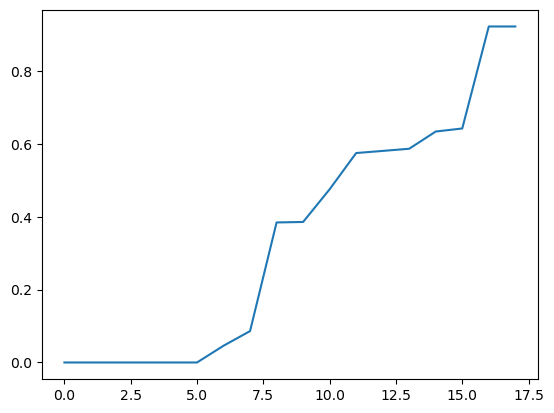

In [24]:
plt.figure()
plt.plot(sorted([gg.coverage_fraction for gg in groups]))

## 5 — Coverage timeline

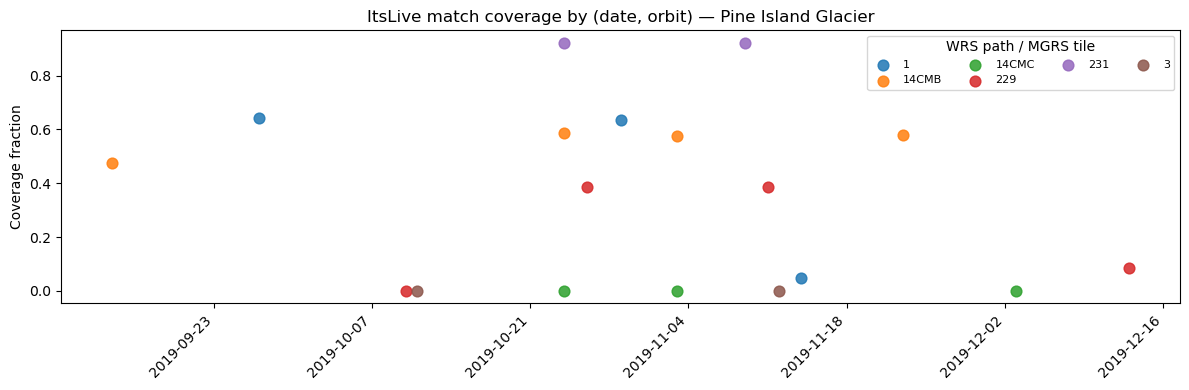

In [25]:
if groups:
    import matplotlib.dates as mdates

    dates  = pd.to_datetime([str(g.acquisition_date) for g in groups])
    fracs  = [g.coverage_fraction for g in groups]
    orbits = [g.wrs_path or g.tile for g in groups]

    unique_orbits = sorted(set(orbits))
    colors = plt.cm.tab10.colors
    orbit_color = {o: colors[i % 10] for i, o in enumerate(unique_orbits)}

    fig, ax = plt.subplots(figsize=(12, 4))
    for o in unique_orbits:
        idx = [i for i, x in enumerate(orbits) if x == o]
        ax.scatter(
            [dates[i] for i in idx],
            [fracs[i] for i in idx],
            label=o,
            color=orbit_color[o],
            s=60, alpha=0.85,
        )

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
    plt.xticks(rotation=45, ha="right")
    ax.set_ylabel("Coverage fraction")
    ax.set_title("ItsLive match coverage by (date, orbit) — Pine Island Glacier")
    ax.legend(title="WRS path / MGRS tile", ncol=4, fontsize=8)
    plt.tight_layout()
    plt.show()

## 6 — Coverage grids for the top groups

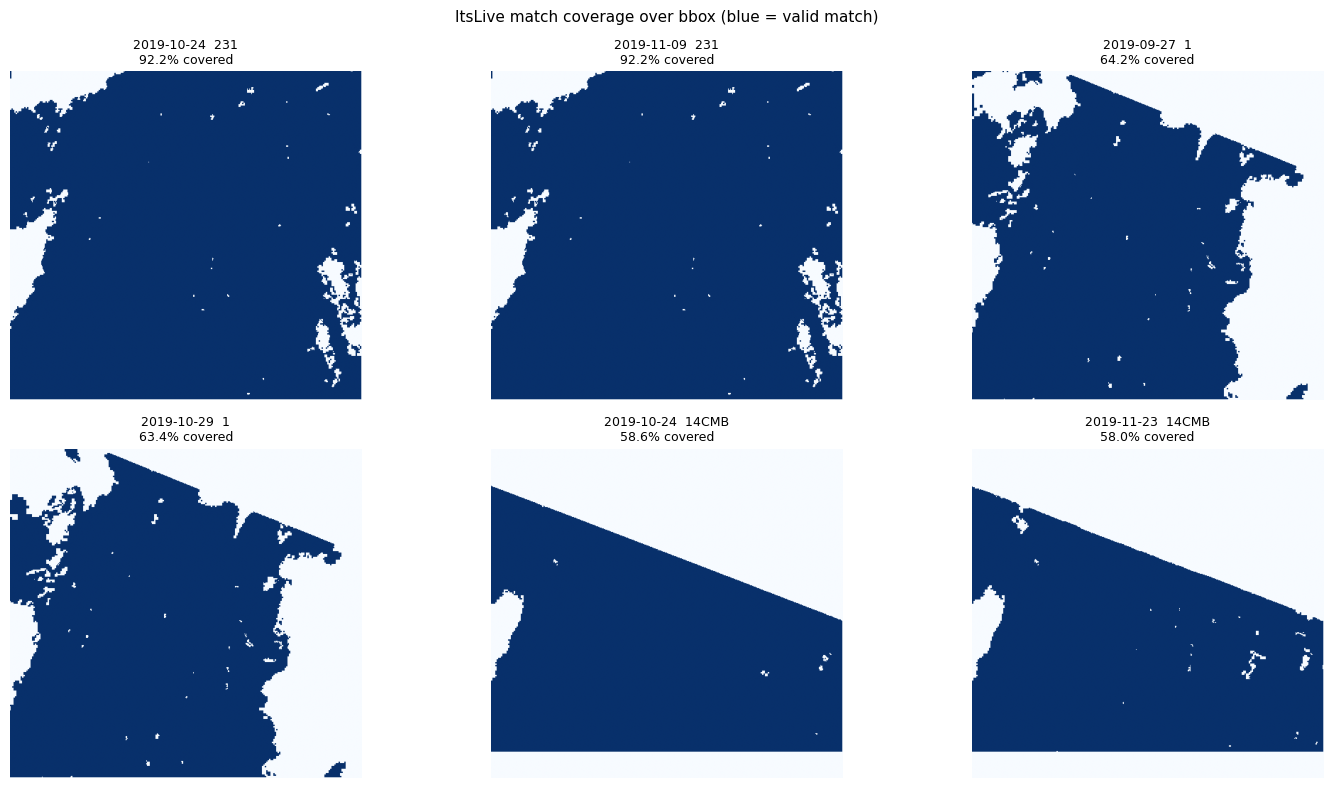

In [26]:
top_n = min(6, len(groups))
if top_n:
    ncols = min(3, top_n)
    nrows = (top_n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).flatten()

    for i, g in enumerate(groups[:top_n]):
        ax = axes[i]
        ax.imshow(g.coverage_grid, cmap="Blues", origin="upper", vmin=0, vmax=1)
        orbit = g.wrs_path or g.tile
        ax.set_title(
            f"{g.acquisition_date}  {orbit}\n"
            f"{g.coverage_fraction:.1%} covered",
            fontsize=9,
        )
        ax.axis("off")

    for j in range(top_n, len(axes)):
        axes[j].axis("off")

    fig.suptitle("ItsLive match coverage over bbox (blue = valid match)", fontsize=11)
    plt.tight_layout()
    plt.show()

## 7 — Red band images for top Sentinel-2 and Landsat scenes

Download the red band (windowed COG read, bbox only) for the top three
Sentinel-2 and top three Landsat groups and display them.

INFO itslive_cloudfree.downloader: Warping 1 source(s) → downloads/S2B_14CMB_20191024_B04.tif
INFO itslive_cloudfree.downloader: Warping 1 source(s) → downloads/S2B_14CMB_20191123_B04.tif
INFO itslive_cloudfree.downloader: Warping 1 source(s) → downloads/S2B_14CMB_20191103_B04.tif
INFO itslive_cloudfree.downloader: Warping 2 source(s) → downloads/LC08_231-114_231-113_20191024_B4.tif
INFO itslive_cloudfree.downloader: Warping 2 source(s) → downloads/LC08_231-114_231-113_20191109_B4.tif
INFO itslive_cloudfree.downloader: Warping 1 source(s) → downloads/LC08_1-113_20190927_B4.tif


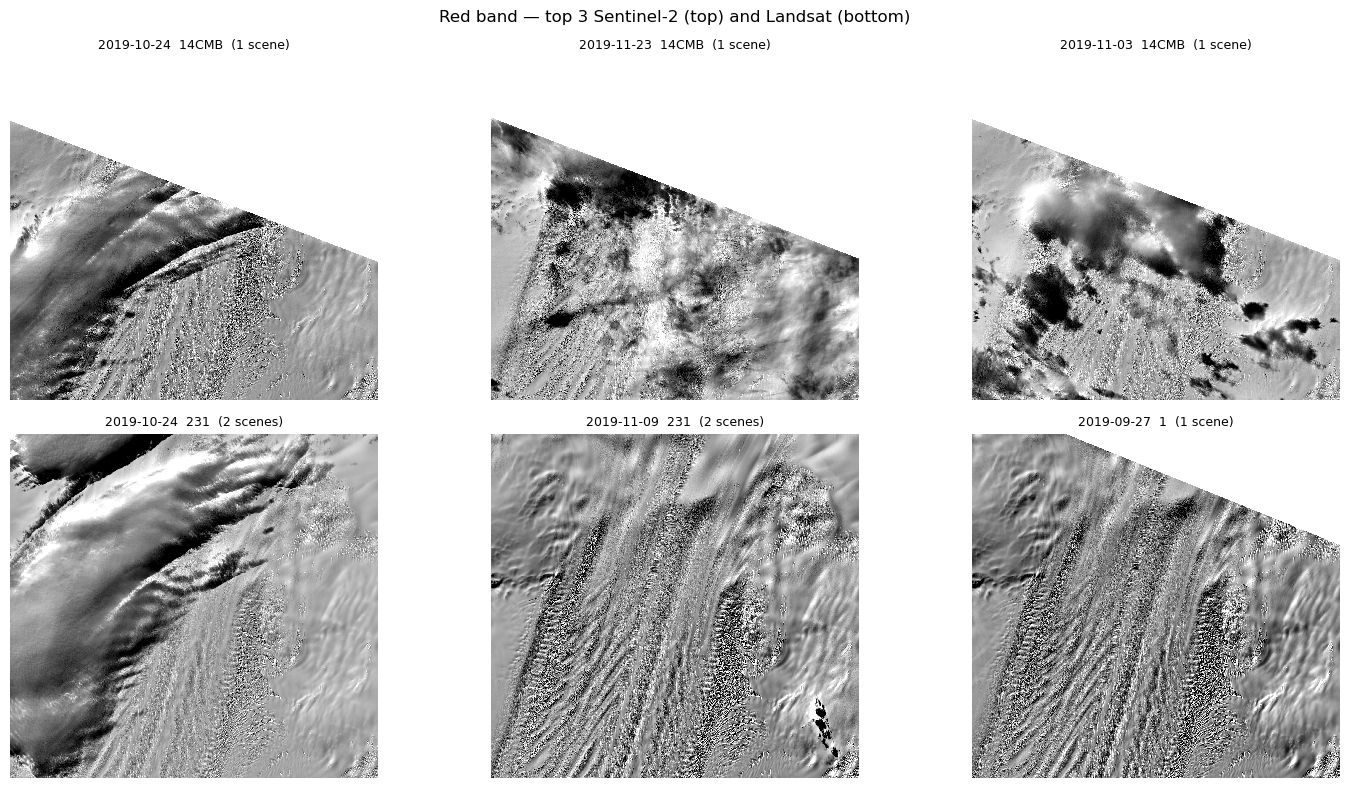

In [27]:
! rm -r downloads/*

logging.basicConfig(level=logging.DEBUG)

import rasterio
import numpy as np
import matplotlib.pyplot as plt
from itslive_cloudfree.downloader import download_scenes_mosaic

s2_groups = [g for g in groups if g.tile     is not None][:3]
ls_groups = [g for g in groups if g.wrs_path is not None][:3]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax_row, group_list in enumerate([s2_groups, ls_groups]):
    for col, g in enumerate(group_list):
        ax = axes[ax_row, col]
        paths = download_scenes_mosaic(
            g.scenes,
            bbox=BBOX, bbox_crs=BBOX_CRS, dst_crs=BBOX_CRS,
            bands=["red"], out_dir="downloads",
        )
        if "red" in paths:
            with rasterio.open(paths["red"]) as src:
                data = src.read(1).astype("float32")
                nodata = src.nodata if src.nodata is not None else 0
            valid = data != nodata
            lo, hi = np.percentile(data[valid], [2, 98]) if valid.any() else (0, 1)
            data = np.clip((data - lo) / max(hi - lo, 1), 0, 1)
            data[~valid] = np.nan
            ax.imshow(data, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
        else:
            ax.text(0.5, 0.5, "not found", ha="center", va="center",
                    transform=ax.transAxes)
        orbit = g.tile or g.wrs_path
        n = len(g.scenes)
        ax.set_title(
            f"{g.acquisition_date}  {orbit}  ({n} scene{'s' if n != 1 else ''})",
            fontsize=9,
        )
        ax.axis("off")

axes[0, 0].set_ylabel("Sentinel-2", fontsize=10)
axes[1, 0].set_ylabel("Landsat",    fontsize=10)

fig.suptitle("Red band — top 3 Sentinel-2 (top) and Landsat (bottom)", fontsize=12)
plt.tight_layout()
plt.show()